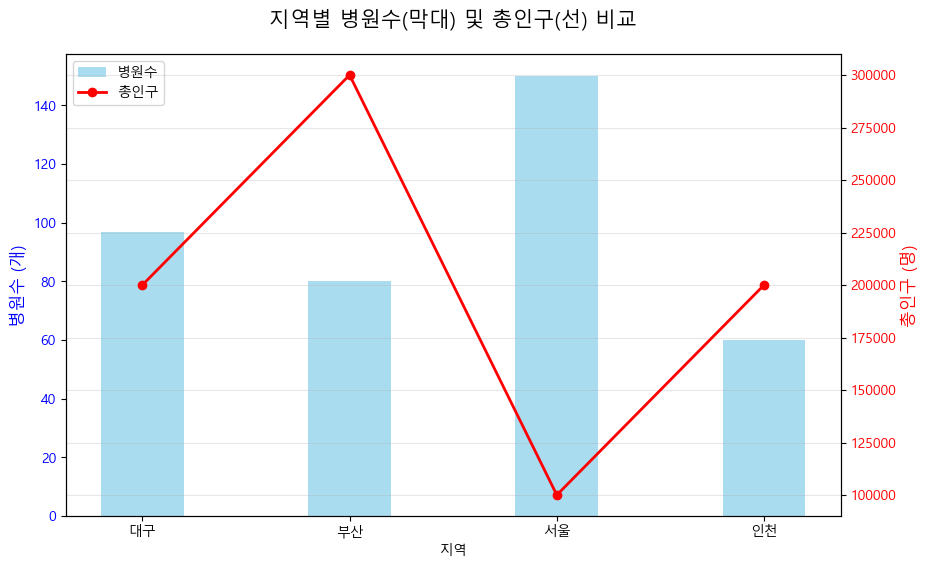

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 생성 (이전과 동일)
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [100000, 300000, 200000]
})

df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150, 80, 60]
})

# 2. 데이터 병합 및 결측치 처리
merged = pd.merge(df1, df2, on="지역", how="outer")
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged["병원수"] = merged["병원수"].fillna(merged["병원수"].mean())

# 지역명 기준으로 정렬 (가독성 증대)
merged = merged.sort_values(by="지역")

# 3. 시각화 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax1 = plt.subplots(figsize=(10, 6))

# --- 첫 번째 Y축 (왼쪽): 병원수 (막대 그래프) ---
ax1.bar(merged["지역"], merged["병원수"], color='skyblue', alpha=0.7, label="병원수", width=0.4)
ax1.set_xlabel("지역")
ax1.set_ylabel("병원수 (개)", color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

# --- 두 번째 Y축 (오른쪽): 총인구 (선 그래프) ---
# twinx()를 사용하여 x축은 공유하고 y축만 새로 만듭니다.
ax2 = ax1.twinx()
ax2.plot(merged["지역"], merged["총인구"], color='red', marker='o', linewidth=2, label="총인구")
ax2.set_ylabel("총인구 (명)", color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# 4. 마무리 설정
plt.title("지역별 병원수(막대) 및 총인구(선) 비교", fontsize=15, pad=20)

# 두 축의 범례를 합쳐서 표시하기
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.grid(axis='y', alpha=0.3)
plt.show()